In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import textwrap, os
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from IPython.display import display, Markdown
from datetime import datetime, timezone, timedelta

sns.set_theme(style='white')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlepad': 14,
    'axes.labelpad': 8,
})

PLOT_DIR = '../results/plots/2026-02_sustainability_month_blog_post'
os.makedirs(PLOT_DIR, exist_ok=True)

# Colours
C_CPU  = '#2196F3'
C_MEM  = '#4CAF50'
C_TIME = '#9C27B0'
C_OK   = '#4CAF50'
C_FAIL = '#F44336'
C_CAN  = '#9E9E9E'
DATE_RANGE = ''

# Faculty abbreviations (used in all plots for readability)
FACULTY_ABBREV = {
    'Faculty of Social Science & Public Policy':                'SSPP',
    'Faculty of Natural, Mathematical & Engineering Sciences':  'NMES',
    'Faculty of Dentistry, Oral & Craniofacial Sciences':       'DOCS',
    'Faculty of Life Sciences & Medicine':                      'LSM',
    'Institute of Psychiatry, Psychology & Neuroscience':       'IoPPN',
    'Faculty of Arts & Humanities':                             'AH',
    'Research Management & Innovation':                         'RMI',
    "King's Business School":                                   'KBS',
    'Students & Education':                                     'SE',
    'The Dickson Poon School of Law':                           'DPSL',
    'IT':                                                       'IT',
    'Other':                                                    'Other',
    'unknown':                                                  'N/A',
}

def approx(n, sf=2):
    """Round to sf significant figures and add k/M suffix."""
    if n == 0:
        return '0'
    mag = 10 ** (len(str(abs(int(n)))) - sf)
    rounded = round(n / mag) * mag
    if rounded >= 1_000_000:
        val = rounded / 1_000_000
        return f'~{val:.0f}M' if val == int(val) else f'~{val:.1f}M'
    if rounded >= 1_000:
        val = rounded / 1_000
        return f'~{val:.0f}k' if val == int(val) else f'~{val:.1f}k'
    return f'~{rounded}'

def fmt_count(x, _):
    """Format job counts: k for thousands, M for millions."""
    if abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x / 1_000:.0f}k'
    else:
        return f'{x:.0f}'

COUNT_FMT = mticker.FuncFormatter(fmt_count)

def savefig(name):
    path = os.path.join(PLOT_DIR, name)
    plt.savefig(path)
    print(f'  Saved {name}')

In [2]:
JOB_CSV = '../results/data/2026-07-24_2026-08-26_job_level_metrics_all_jobs.csv'

# --- Job-level data ---
df = pd.read_csv(JOB_CSV, comment='#')
df['faculty'] = df['faculty'].str.strip('"')
df = df.replace('NULL', np.nan)

num_cols = [c for c in df.columns
            if c not in ('username', 'faculty', 'submission_type', 'mem_type', 'partition')]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

dt_cols = ['time_start', 'time_end']
for c in dt_cols:
    df[c] = pd.to_datetime(df[c], unit = "s", utc=True)

FACULTY_MERGE = {
    'Faculty of Life Sciences and Medicine':
        'Faculty of Life Sciences & Medicine',
    'IoPPN':
        'Institute of Psychiatry, Psychology & Neuroscience',
    'Dentistry, Oral & Craniofacial Sciences':
        'Faculty of Dentistry, Oral & Craniofacial Sciences',
    'Social Science & Public Policy':
        'Faculty of Social Science & Public Policy',
}
df['faculty'] = df['faculty'].replace(FACULTY_MERGE)

# Use abbreviations for plot labels
df['faculty_short'] = df['faculty'].map(FACULTY_ABBREV).fillna(df['faculty'])
SHORT = dict(zip(df['faculty'], df['faculty_short']))

total_eff = len(df)
print(f'Included jobs: {total_eff:,}  (COMPLETED + TIMEOUT + OOM)')

Included jobs: 780,118  (COMPLETED + TIMEOUT + OOM)


In [3]:
df.columns

Index(['job_id', 'username', 'faculty', 'submission_type', 'step_count',
       'state', 'exit_code', 'is_success', 'time_start', 'time_end',
       'partition', 'elapsed_sec', 'wait_sec', 'timelimit_sec', 'cpu_eff_req',
       'cpu_eff_alloc', 'mem_eff', 'mem_eff_alloc', 'time_eff',
       'total_cpu_sec', 'user_cpu_sec', 'sys_cpu_sec', 'user_cpu_pct',
       'maxrss_bytes', 'reqmem_bytes', 'allocmem_bytes', 'mem_type',
       'req_cpus', 'alloc_cpus', 'req_gpus', 'alloc_gpus', 'n_nodes',
       'n_tasks', 'submit_line_ntasks', 'submit_line_cpus_per_task',
       'submit_line_interactive', 'faculty_short'],
      dtype='str')

## Job state identification

In [4]:
# Jobs that never started
# state 4 is cancelled - makes sense
df[df['time_start'] == datetime.fromtimestamp(0, tz=timezone.utc)]['state'].value_counts()

state
4    30219
5      623
0      236
7       45
Name: count, dtype: int64

In [5]:
# Jobs with non-zero start time
# Some of these state codes are not in Nadine's analysis - need investigation
df[df['time_start'] > datetime.fromtimestamp(0, tz=timezone.utc)]['state'].value_counts()

state
3       578948
5        72603
1024     48182
4        17814
6        16372
8         7968
11        5545
7         1522
1           41
Name: count, dtype: int64

In [6]:
print(df['state'].value_counts())
JOB_STATE_COMPLETED = 3
JOB_STATE_CANCELLED = 4
JOB_STATE_FAILED = 5
JOB_STATE_TIMEOUT = 6
JOB_STATE_NODE_FAIL = 7
JOB_STATE_PREEMPTED = 8
JOB_STATE_OUT_OF_MEMORY = 11



state
3       578948
5        73226
1024     48182
4        48033
6        16372
8         7968
11        5545
7         1567
0          236
1           41
Name: count, dtype: int64


### Job state 1024 ~= CANCELLED

```
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 35987187
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
35987187     k25049595        kcl     create            CANCELLED by 982561

k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 35987662
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
35987662_0    k2480441        kcl     create            CANCELLED by 939128 
35987662_0.+                  kcl     create                      CANCELLED 
35987662_1    k2480441        kcl     create                         FAILED 
35987662_1.+                  kcl     create                         FAILED 
35987662_2    k2480441        kcl     create                         FAILED 
35987662_2.+                  kcl     create                         FAILED 
35987662_3    k2480441        kcl     create                         FAILED 
35987662_3.+                  kcl     create                         FAILED 
35987662_4    k2480441        kcl     create            CANCELLED by 939128 
35987662_5    k2480441        kcl     create            CANCELLED by 939128 
35987662_6    k2480441        kcl     create            CANCELLED by 939128 

k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 35987765
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
35987662_4    k2480441        kcl     create            CANCELLED by 939128 

k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36680931
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36680931     k23123957        kcl     create                      PREEMPTED 
36680931.ba+                  kcl     create                      CANCELLED 

k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36681085
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36681085     k23123957        kcl     create                        TIMEOUT 
36681085.ba+                  kcl     create                      CANCELLED 

k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36639702 
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36631271_1   k25042421        kcl     create                      PREEMPTED 
36631271_1.+                  kcl     create                      CANCELLED 

k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36631271
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36631271_0   k25042421        kcl     create                      PREEMPTED 
36631271_0.+                  kcl     create                      CANCELLED 
36631271_1   k25042421        kcl     create                      PREEMPTED 
36631271_1.+                  kcl     create                      CANCELLED 
36631271_2   k25042421        kcl     create                      PREEMPTED 
36631271_2.+                  kcl     create                      CANCELLED 
```

### Job state 0 = PENDING

```
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 35989257
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
35989257     k25039405 er_prj_en+     create                        PENDING 
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 35989258
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
35989258     k25039405 er_prj_en+     create                        PENDING 
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 35990286
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
35990286     k25039405 er_prj_en+     create                        PENDING 
```

### Job state 1 = RUNNING (?)

```
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36536630
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36536630     k22018655        kcl     create                         FAILED 
36536630.ba+                  kcl     create                         FAILED 
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36536631
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36536631     k22018655        kcl     create            CANCELLED by 771290 

k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36547228
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36547228      k2262470        kcl     create                        RUNNING 
36547228.ba+                  kcl     create                        RUNNING 
36547228.0                    kcl     create                      COMPLETED 
36547228.1                    kcl     create                      COMPLETED 
36547228.2                    kcl     create                      COMPLETED 
36547228.3                    kcl     create                      COMPLETED 
36547228.4                    kcl     create                      COMPLETED 
36547228.5                    kcl     create                      COMPLETED 
36547228.6                    kcl     create                      COMPLETED 
36547228.7                    kcl     create                      COMPLETED 
36547228.8                    kcl     create                      COMPLETED 
36547228.9                    kcl     create                      COMPLETED 
36547228.10                   kcl     create                      COMPLETED 
36547228.11                   kcl     create                      COMPLETED 
36547228.12                   kcl     create                      COMPLETED 
36547228.13                   kcl     create                      COMPLETED 
36547228.14                   kcl     create                      COMPLETED 
36547228.15                   kcl     create                      COMPLETED 
36547228.16                   kcl     create                      COMPLETED 
36547228.17                   kcl     create                      COMPLETED 
36547228.18                   kcl     create                      COMPLETED 
36547228.19                   kcl     create                      COMPLETED 
36547228.20                   kcl     create                      COMPLETED 
36547228.21                   kcl     create                        RUNNING 
36547228.22                   kcl     create                        RUNNING 
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36547339
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36547339     k21114527        kcl     create                        RUNNING 
36547339.ba+                  kcl     create                        RUNNING 
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36547739
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36547739     k21114527        kcl     create                        RUNNING 
36547739.ba+                  kcl     create                        RUNNING 
k2474365@erc-hpc-login1:~$ sacct -o "jobid,user,account,cluster,state%30"   -j 36759029
JobID             User    Account    Cluster                          State 
------------ --------- ---------- ---------- ------------------------------ 
36697541_262  k2367182        kcl     create                      COMPLETED 
36697541_26+                  kcl     create                      COMPLETED 
```

## Function definitions

In [7]:
unix_zerotime = pd.to_datetime("1970-01-01 00:00", utc=True)

In [8]:
def most_jobs_in_range(df, start, end, top_n=10):
    range_data = df[ (df['time_start'] > unix_zerotime) &
                        (df['time_start'] < start) & 
                        ((df['time_end'] > end) | (df['time_end'] == unix_zerotime))]
    
    counts = range_data['username'].value_counts()

    # Keep top N, group the rest
    top_N = counts.head(top_n)
    other = pd.Series({'other': counts.iloc[top_n:].sum()})

    summary = pd.concat([top_N, other])

    return summary

In [9]:
def most_cpus_in_range(df, start, end, top_n=10):
    range_data = df[ (df['time_start'] > unix_zerotime) &
                        (df['time_start'] < start) & 
                        ((df['time_end'] > end) | (df['time_end'] == unix_zerotime))]
    
    counts = range_data.groupby(['username'])['alloc_cpus'].sum().sort_values(ascending=False)

    # Keep top N, group the rest
    top_N = counts.head(top_n)
    other = pd.Series({'other': counts.iloc[top_n:].sum()})

    summary = pd.concat([top_N, other])

    return summary

def most_gpus_in_range(df, start, end, top_n=10):
    range_data = df[ (df['time_start'] > unix_zerotime) &
                        (df['time_start'] < start) & 
                        ((df['time_end'] > end) | (df['time_end'] == unix_zerotime))]
    
    counts = range_data.groupby(['username'])['alloc_gpus'].sum().sort_values(ascending=False)

    # Keep top N, group the rest
    top_N = counts.head(top_n)
    other = pd.Series({'other': counts.iloc[top_n:].sum()})

    summary = pd.concat([top_N, other])

    return summary

In [10]:
def plot_usage_in_range(df, start, end, count_by="jobs", freq="h", top_n=10, norm=False):
    timestamps = pd.date_range(start=start, end=end, freq=freq)

    if count_by == "jobs":
        summaries = { ts: most_jobs_in_range(df, ts, ts + timedelta(minutes=1), top_n) for ts in timestamps}
        y_lab = "Job"
    elif count_by == "cpus":
        summaries = { ts: most_cpus_in_range(df, ts, ts + timedelta(minutes=1), top_n) for ts in timestamps}
        y_lab = "CPU"
    elif count_by == "gpus":
        summaries = { ts: most_gpus_in_range(df, ts, ts + timedelta(minutes=1), top_n) for ts in timestamps}
        y_lab = "GPU"
    else:
        raise ValueError("'count_by' must be either 'jobs', 'cpus', or 'gpus'!")
    
    timestamps = [k for k in summaries]
    if norm:
        data = [v[::-1]/v.sum() for v in summaries.values()]
    else:
        data = [v[::-1] for v in summaries.values()]

    n = top_n + 1
    n_timestamps = len(timestamps)

    # Colour by rank position: darkest at top (largest), lightest at bottom
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, n))[::-1]
    colors[0] = np.array([0.8, 0.8, 0.8, 1.0])  # grey for "other"

    fig, ax = plt.subplots(figsize=(10, 6))
    x_labs = [dt.strftime('%Y-%m-%d %H:%M') if dt.hour in {0, 12} else '' for dt in timestamps]
    x = range(len(timestamps))

    bottom = np.zeros(n_timestamps)
    for i in range(n):
        vals = np.array([
            d.iloc[i] if i < len(d) else 0
            for d in data
        ])
        ax.bar(x, vals, bottom=bottom, color=colors[i])

        bottom += vals

    # Label the top user at each timepoint
    for j in range(n_timestamps):
        username = data[j].index[-1]
        top_val = data[j].iloc[-1]
        if top_val > 0:
            ax.text(j, bottom[j] - top_val / 2, username,
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold', rotation=90)

    if norm:
        y_lab = y_lab + ' Fraction'
    else:
        y_lab = y_lab + ' Count'

    ax.set_ylabel(y_lab)
    plt.axvline(x=27.5/3, color="r", ls="--")

    plt.tight_layout()
    plt.xticks(x, x_labs, rotation=45, ha="right")
    plt.show()

## All partitions

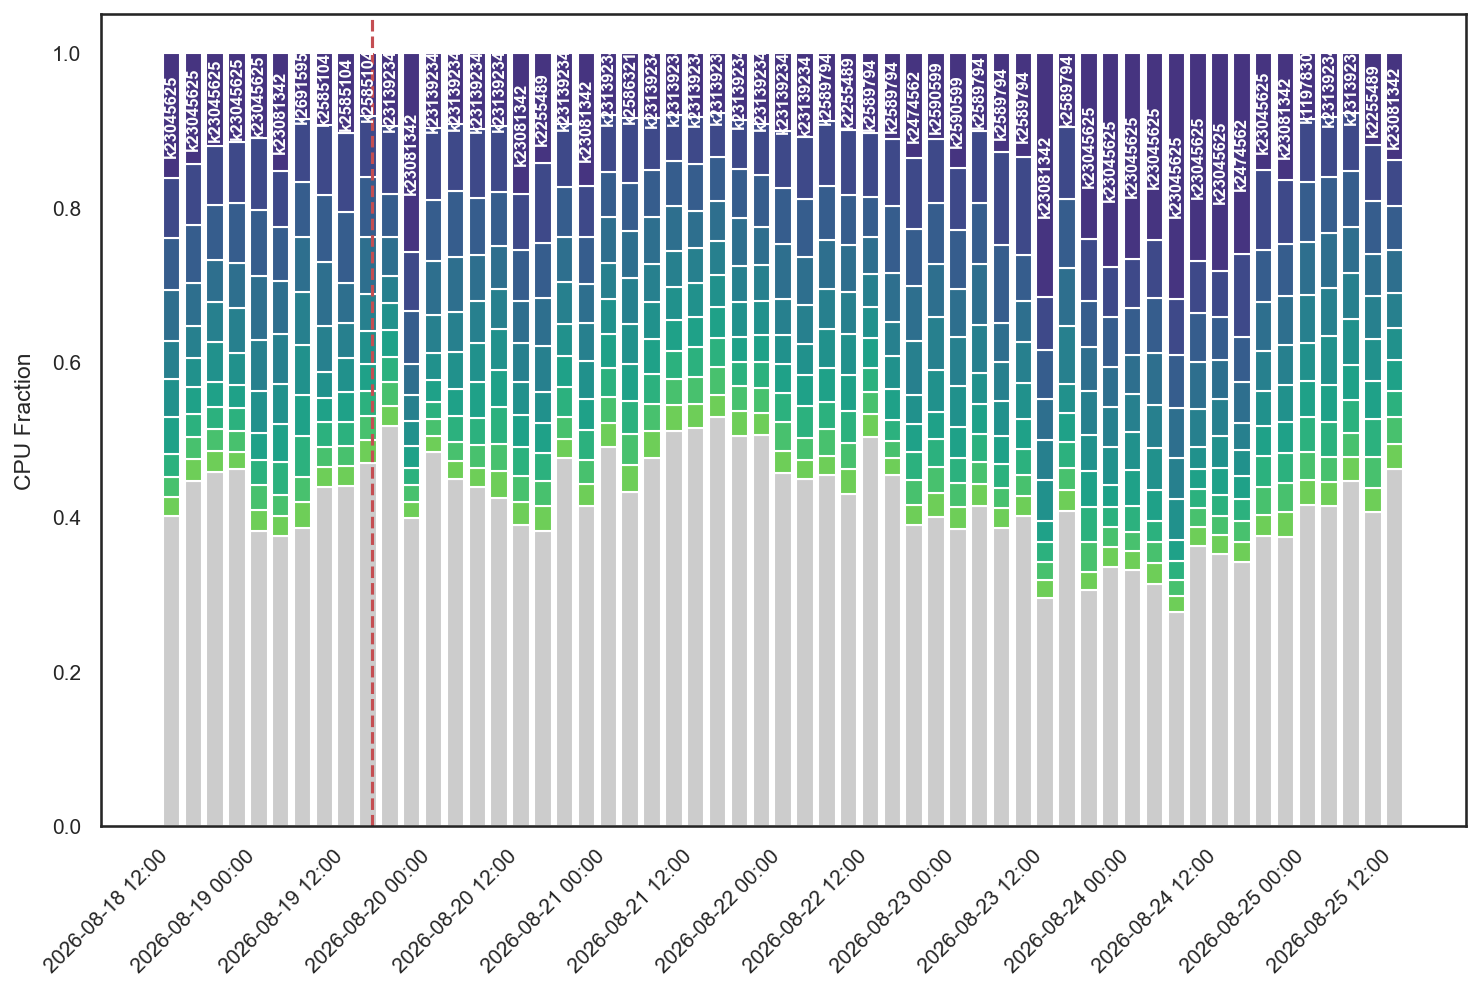

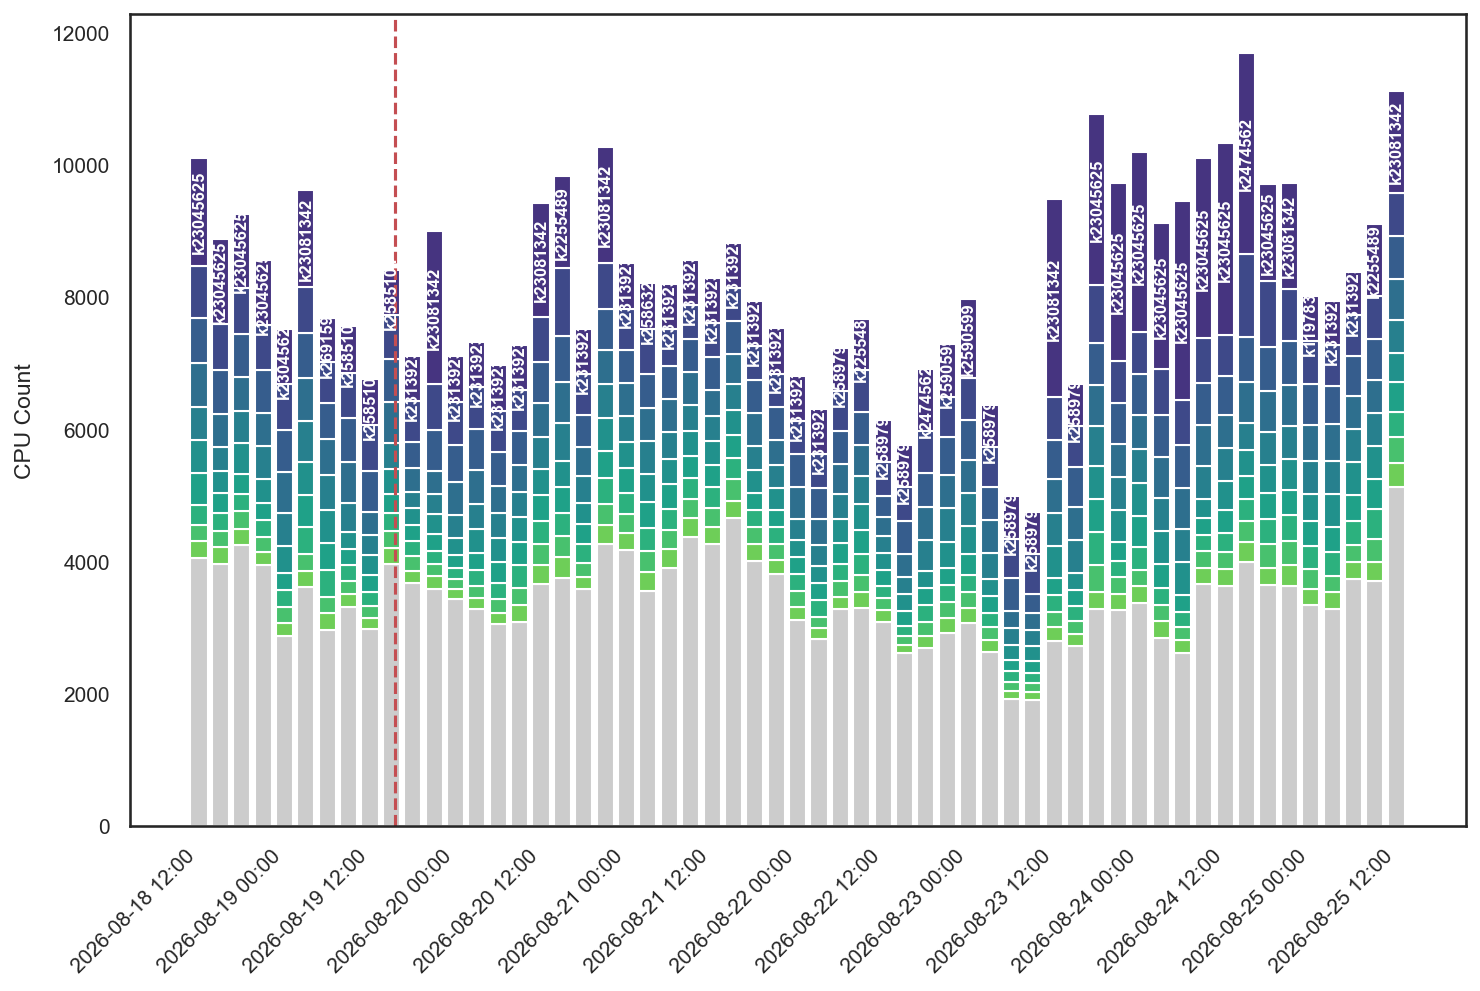

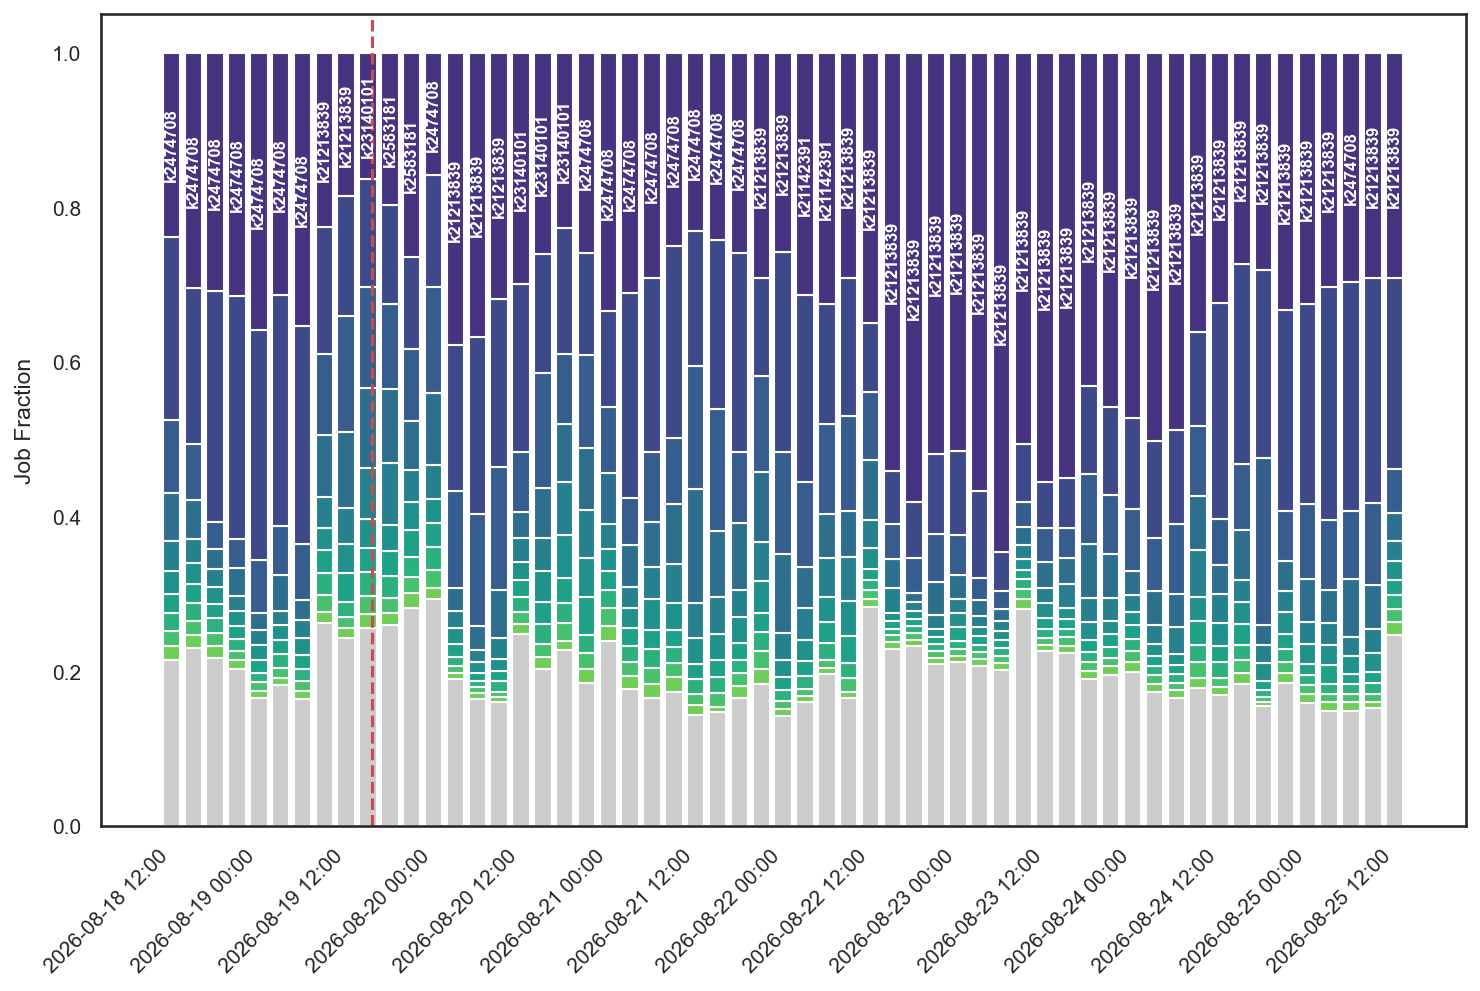

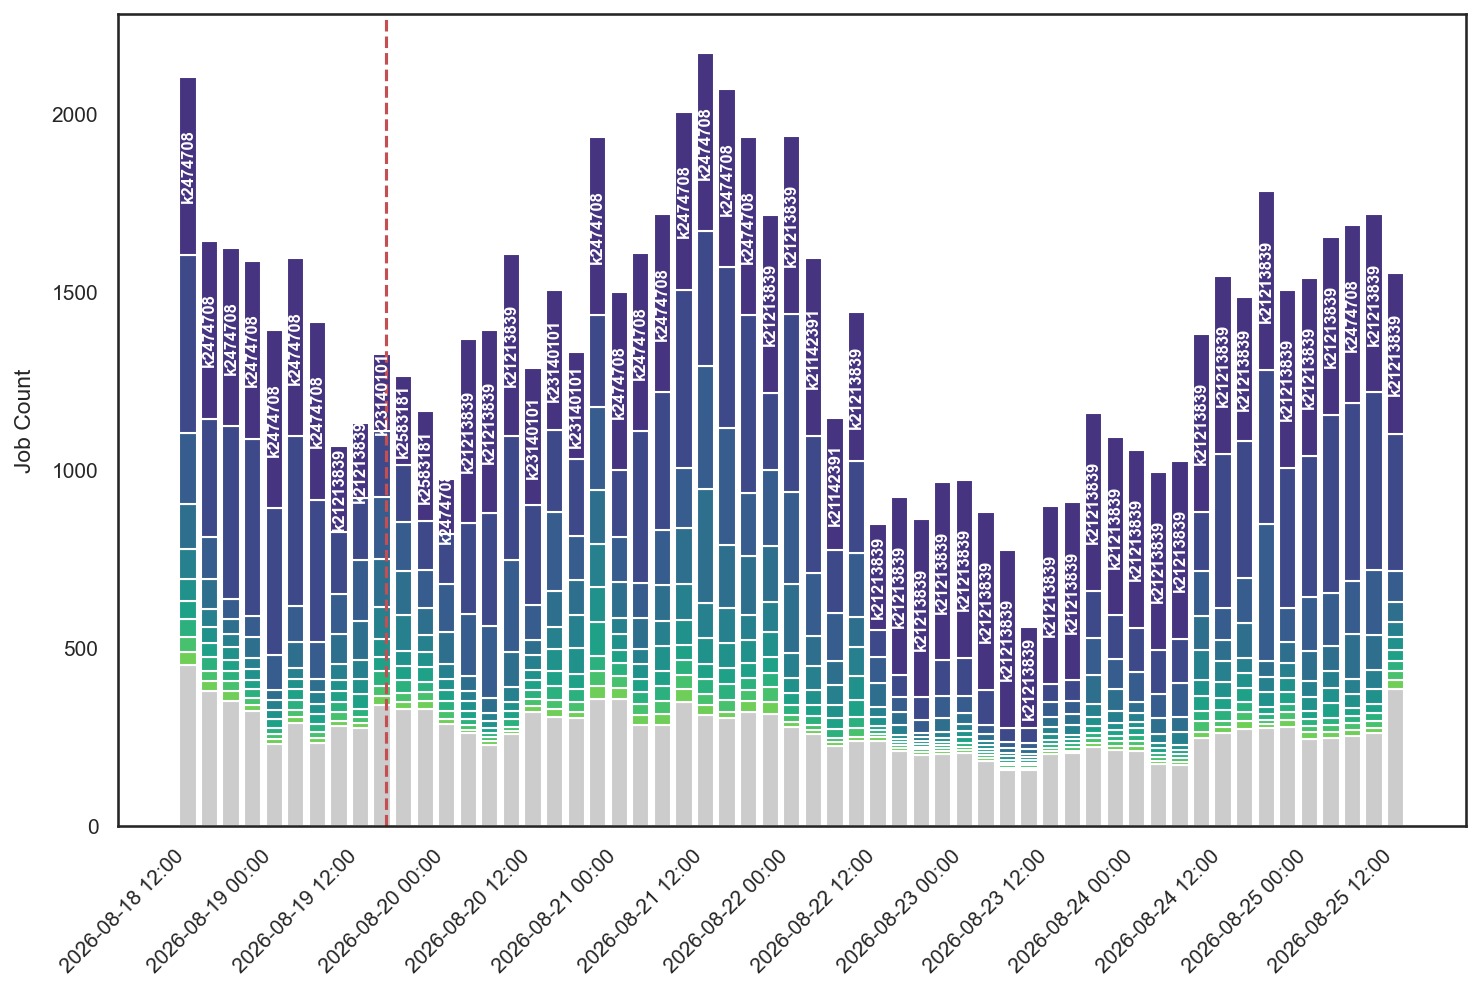

In [11]:
analysis_start = pd.to_datetime("2026-08-18 12:00", utc=True)
analysis_end = pd.to_datetime("2026-08-25 12:00", utc=True)

plot_usage_in_range(df, analysis_start, analysis_end, norm=True, count_by="cpus", freq="3h")
plot_usage_in_range(df, analysis_start, analysis_end, norm=False, count_by="cpus", freq="3h")
plot_usage_in_range(df, analysis_start, analysis_end, norm=True, count_by="jobs", freq="3h")
plot_usage_in_range(df, analysis_start, analysis_end, norm=False, count_by="jobs", freq="3h")

## CPU partition only

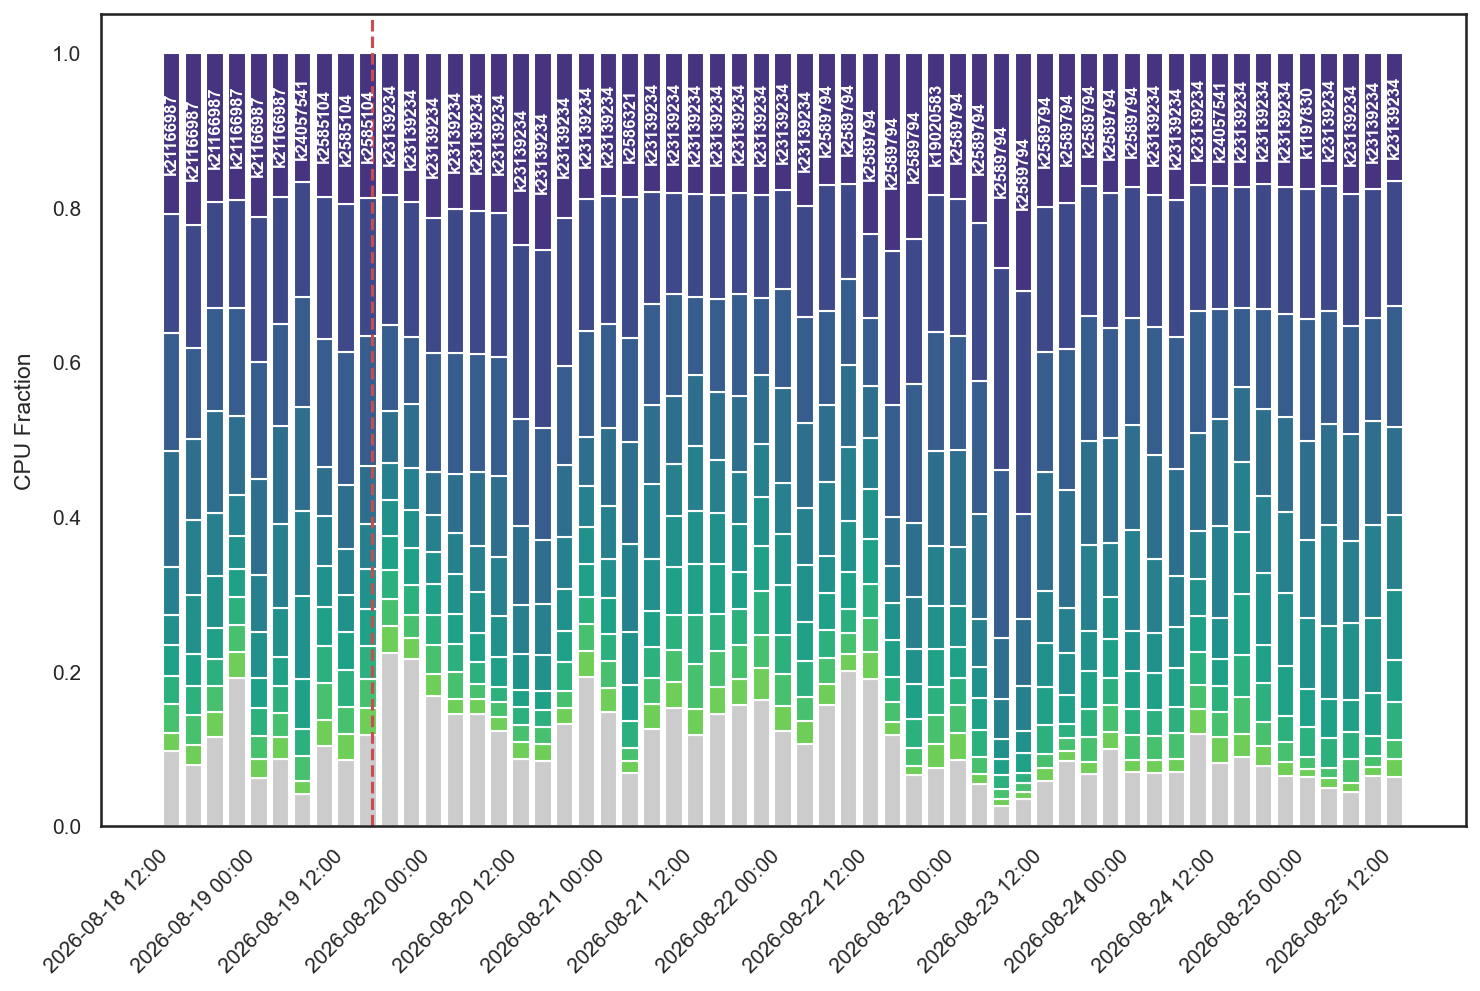

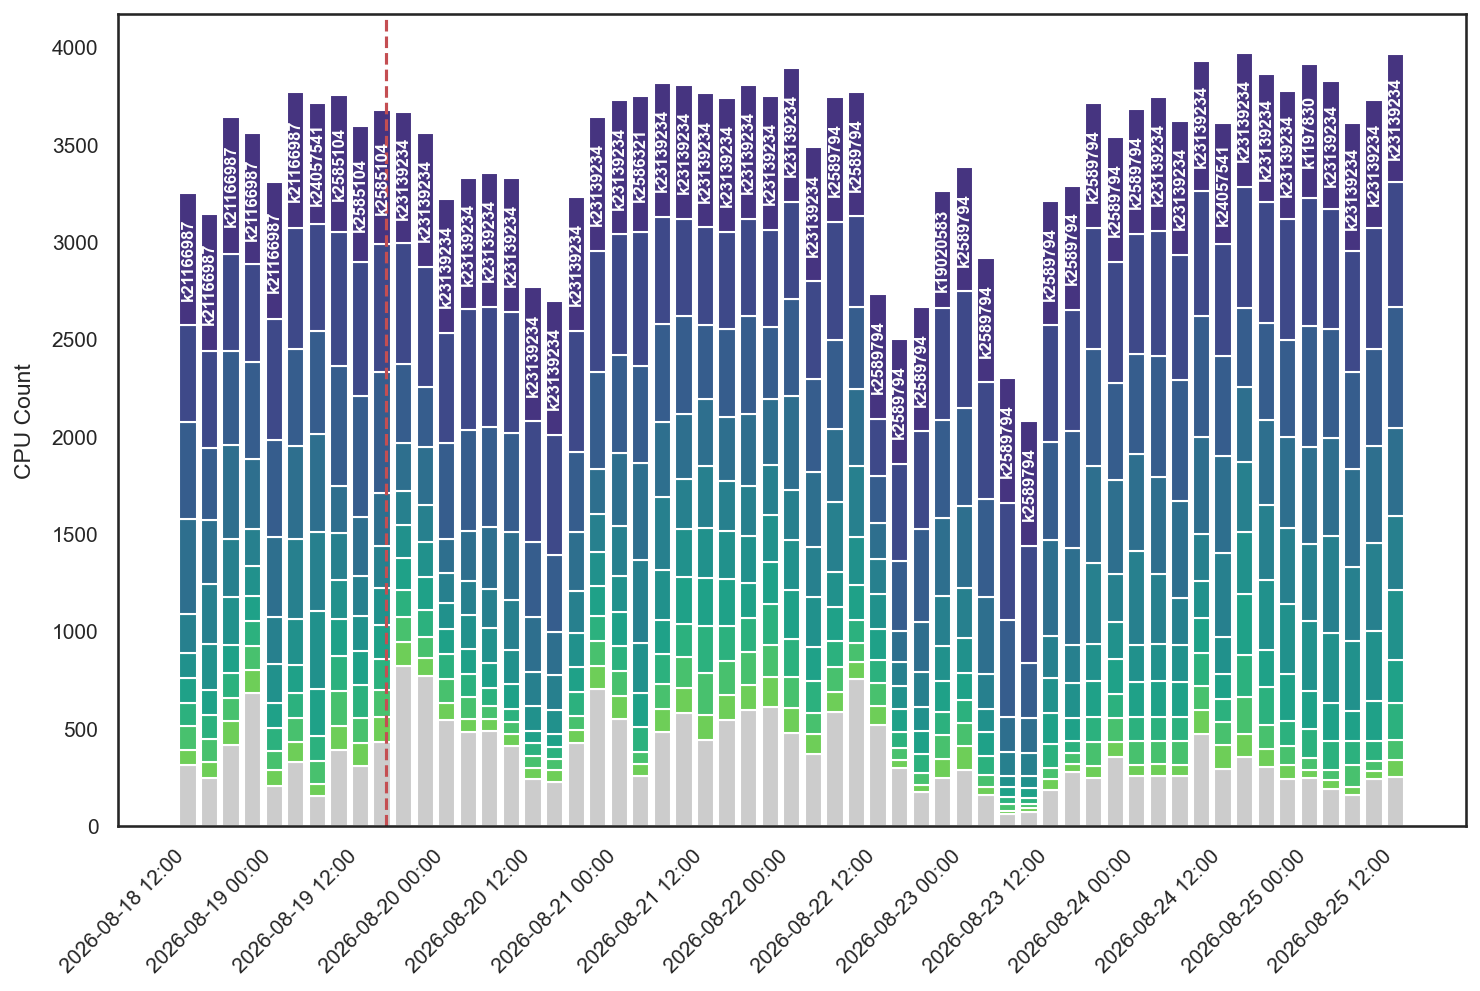

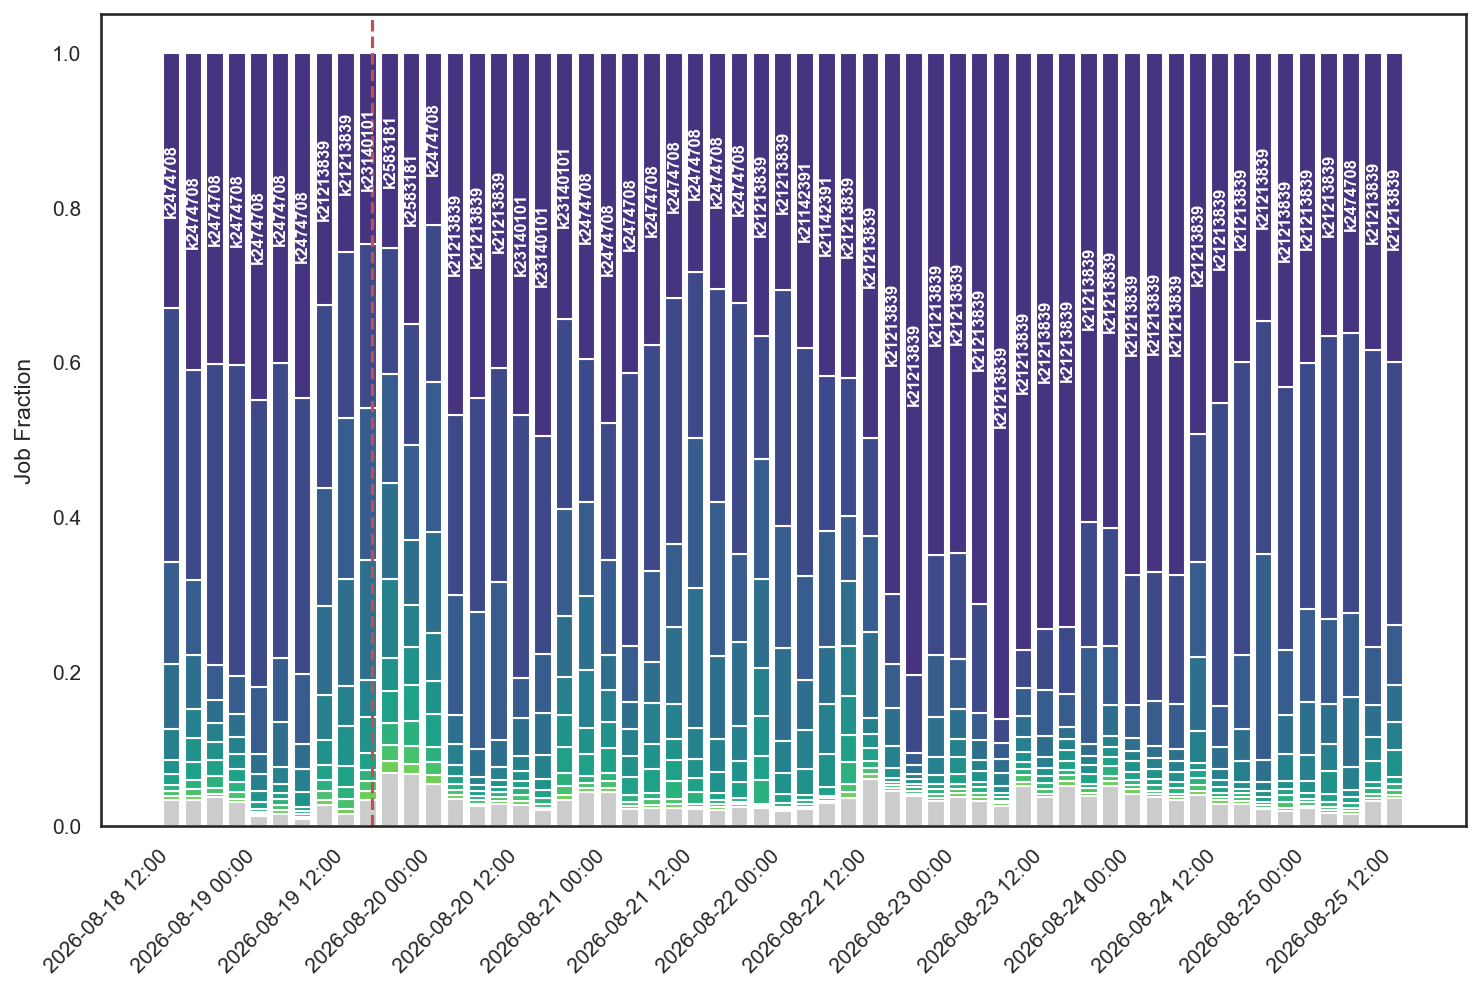

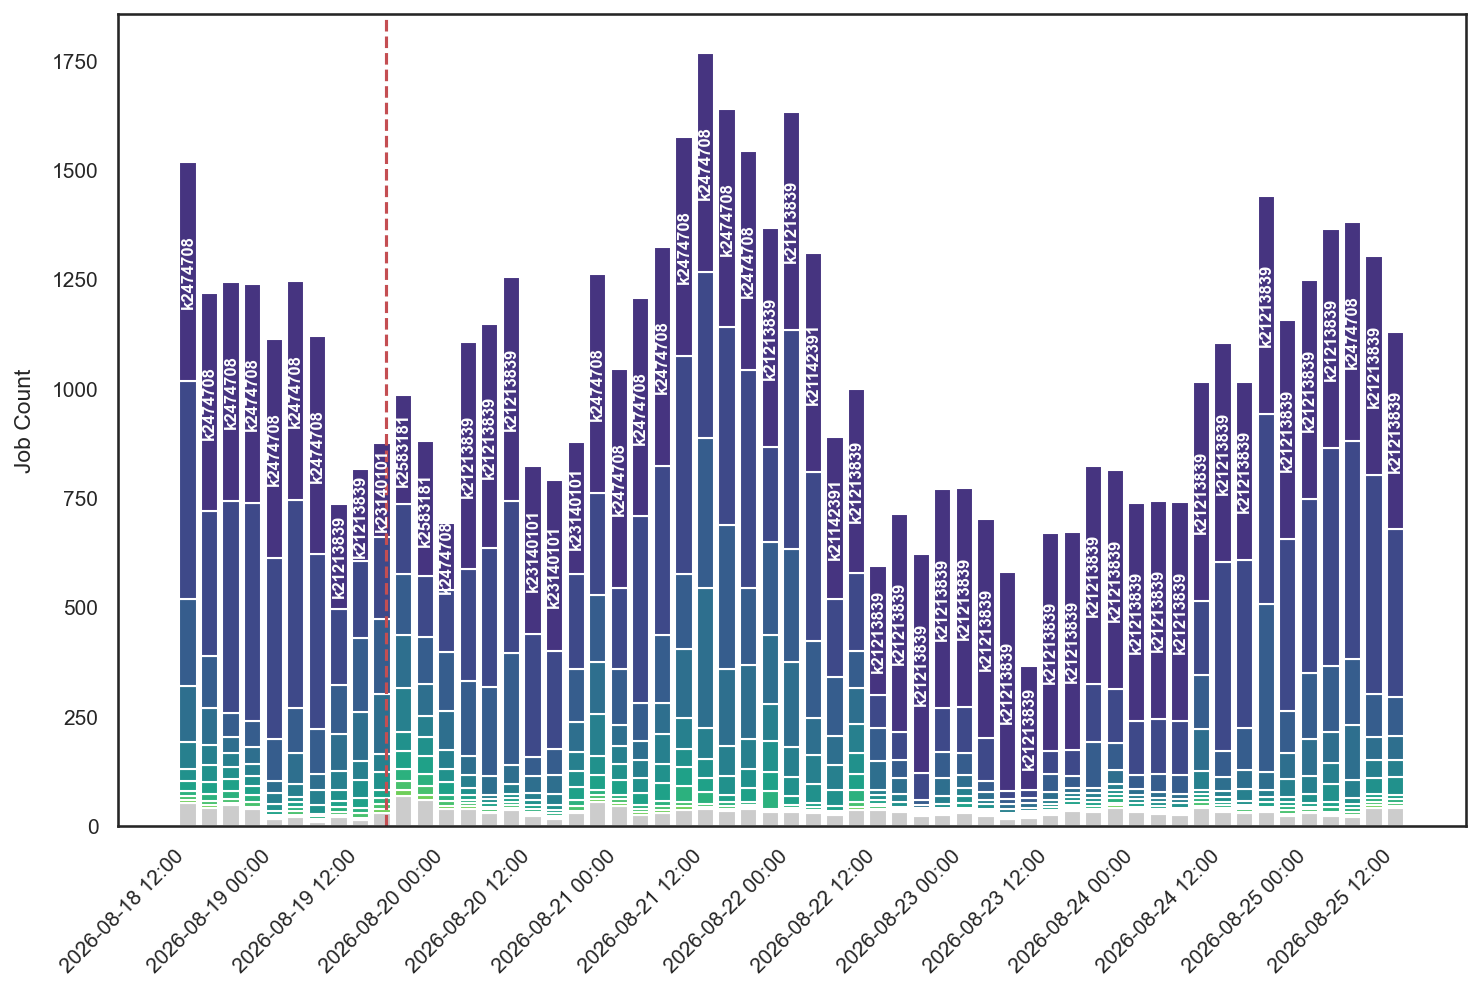

In [12]:
cpu_partition_df = df[df["partition"] == "cpu"]
analysis_start = pd.to_datetime("2026-08-18 12:00", utc=True)
analysis_end = pd.to_datetime("2026-08-25 12:00", utc=True)

plot_usage_in_range(cpu_partition_df, analysis_start, analysis_end, norm=True, count_by="cpus", freq="3h")
plot_usage_in_range(cpu_partition_df, analysis_start, analysis_end, norm=False, count_by="cpus", freq="3h")
plot_usage_in_range(cpu_partition_df, analysis_start, analysis_end, norm=True, count_by="jobs", freq="3h")
plot_usage_in_range(cpu_partition_df, analysis_start, analysis_end, norm=False, count_by="jobs", freq="3h")

## GPU partition only

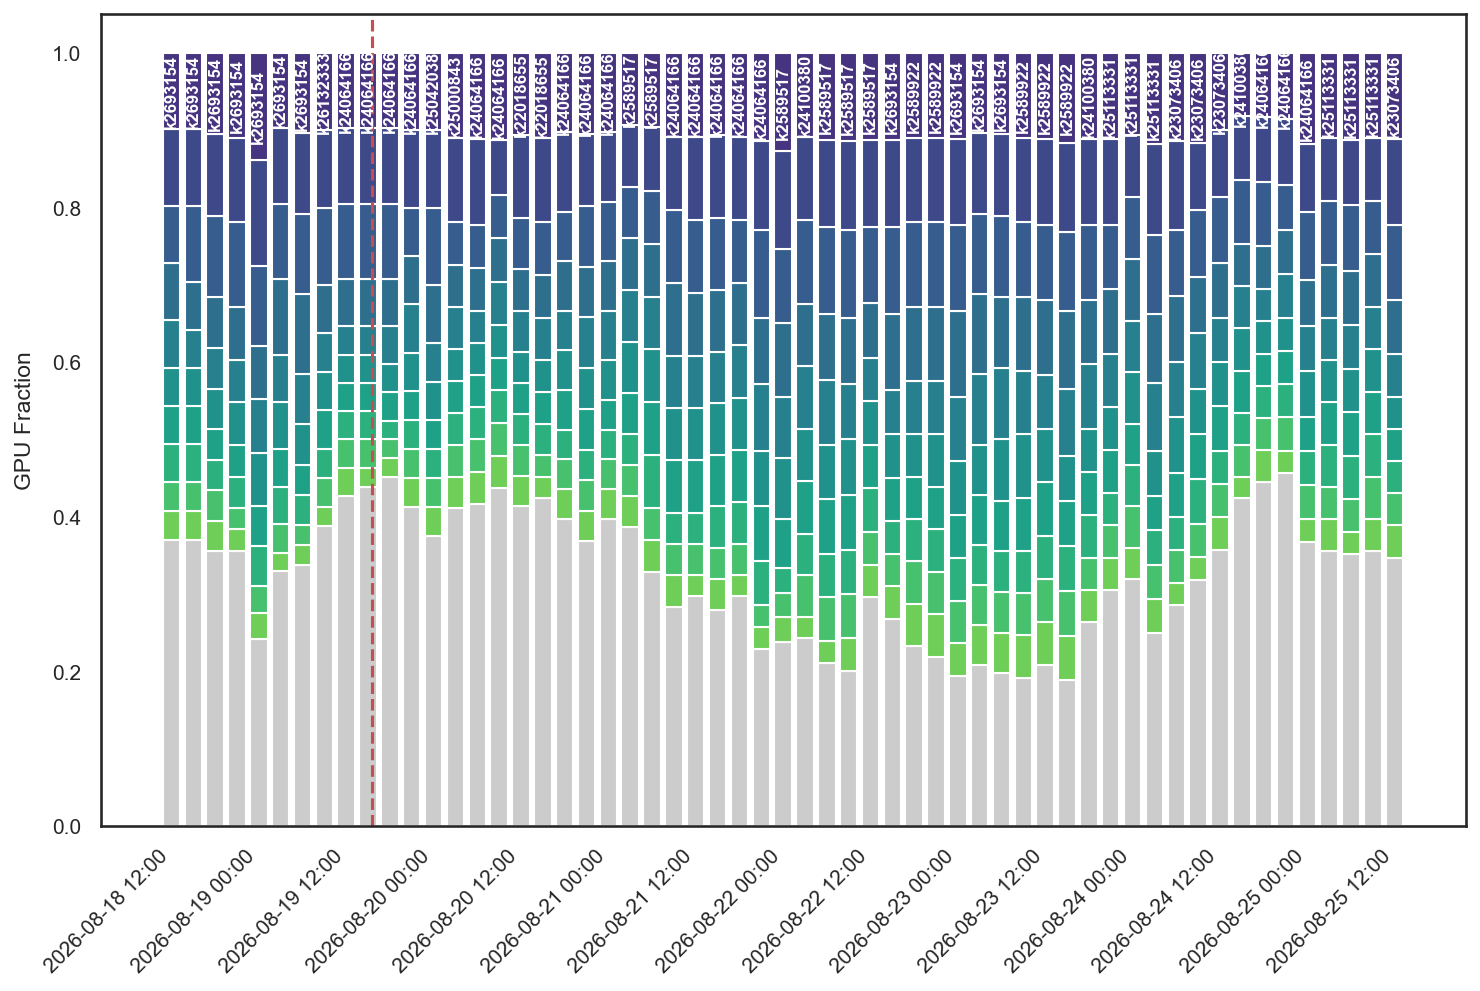

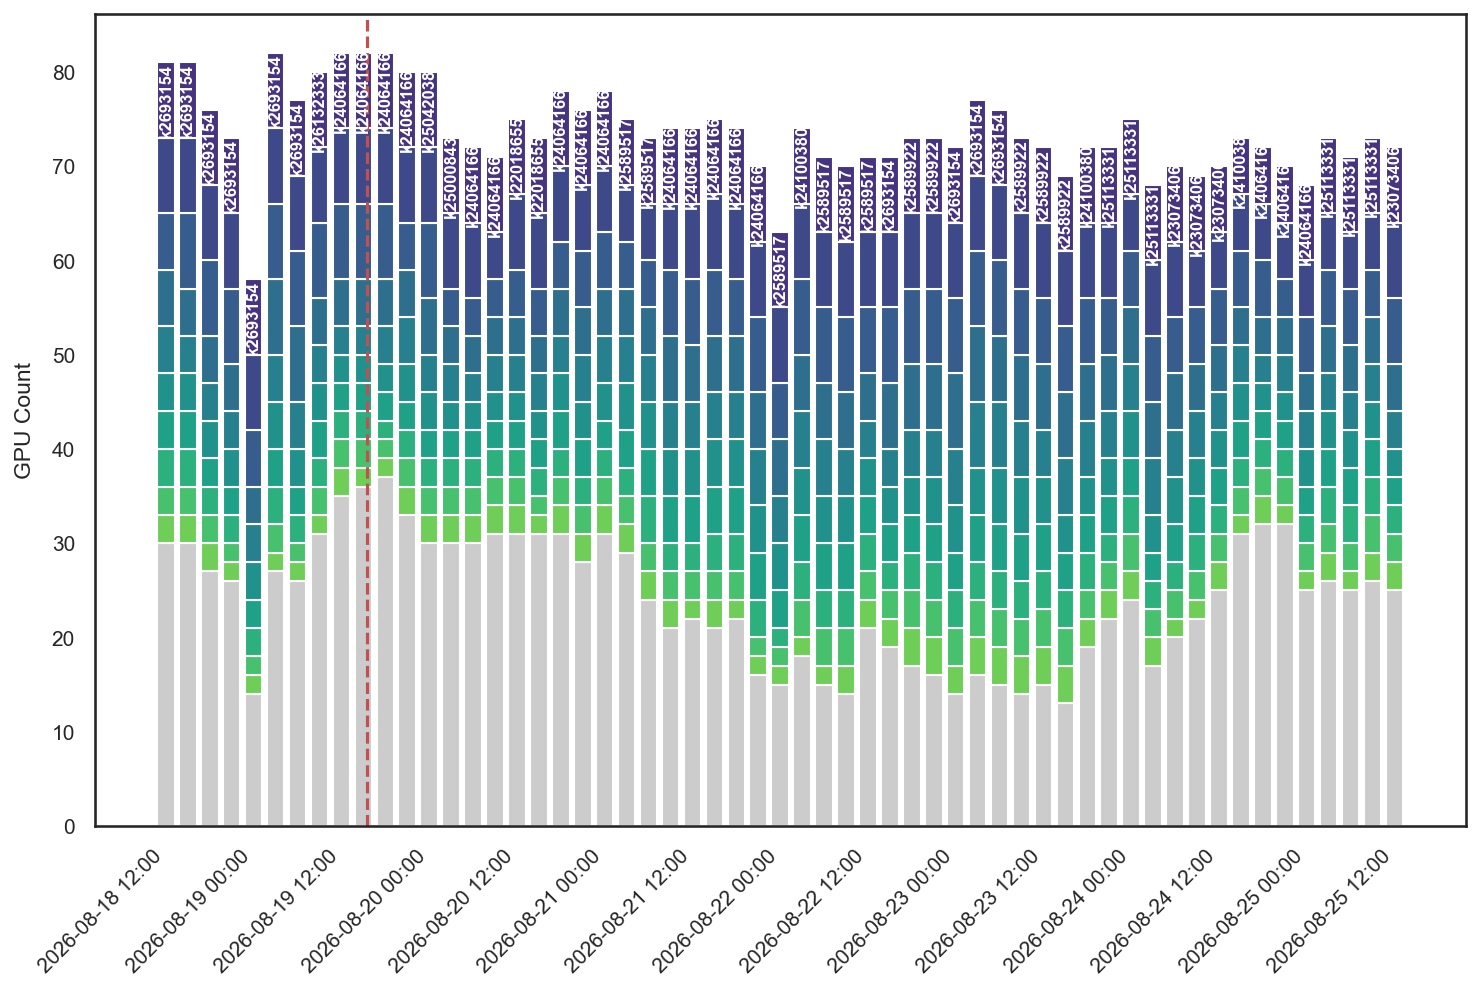

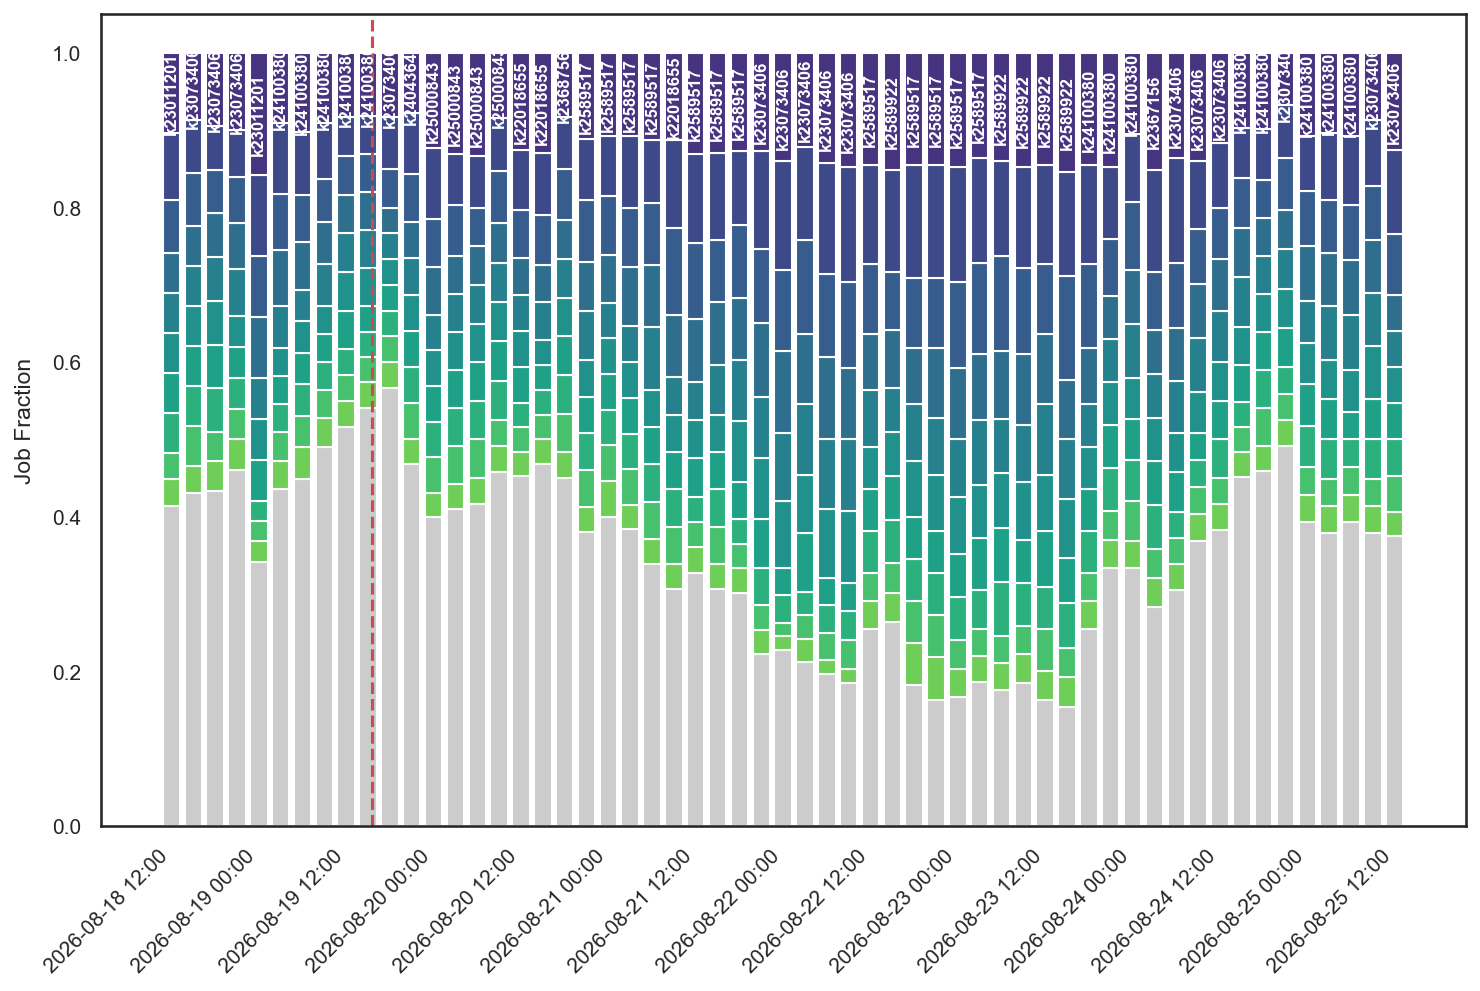

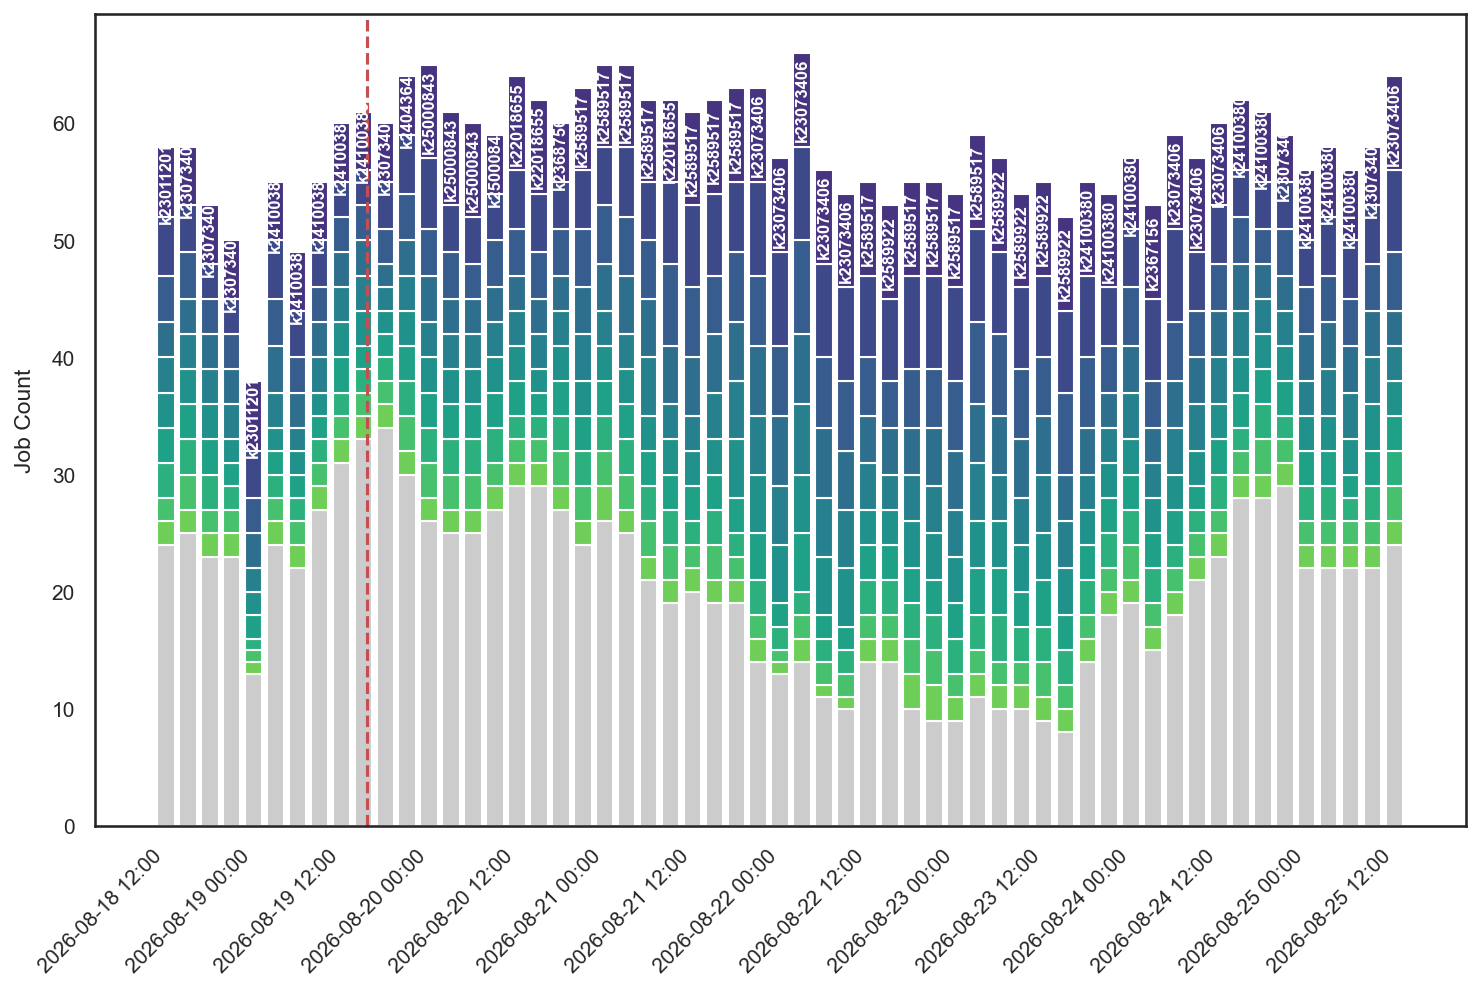

In [13]:
gpu_partition_df = df[df["partition"] == "gpu"]

analysis_start = pd.to_datetime("2026-08-18 12:00", utc=True)
analysis_end = pd.to_datetime("2026-08-25 12:00", utc=True)

plot_usage_in_range(gpu_partition_df, analysis_start, analysis_end, norm=True, count_by="gpus", freq="3h")
plot_usage_in_range(gpu_partition_df, analysis_start, analysis_end, norm=False, count_by="gpus", freq="3h")
plot_usage_in_range(gpu_partition_df, analysis_start, analysis_end, norm=True, count_by="jobs", freq="3h")
plot_usage_in_range(gpu_partition_df, analysis_start, analysis_end, norm=False, count_by="jobs", freq="3h")

## Measuring active users

In [14]:
input_file1 = "../results/data/2022-05-01_2024-08-31_job_level_metrics_all_jobs.csv"
input_file2 = "../results/data/2024-08-26_2026-08-26_job_level_metrics_all_jobs.csv"
def read_job_metrics(input_file):
    df = pd.read_csv(input_file, comment='#')
    df['faculty'] = df['faculty'].str.strip('"')
    df = df.replace('NULL', np.nan)

    num_cols = [c for c in df.columns
                if c not in ('username', 'faculty', 'submission_type', 'mem_type', 'partition')]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    dt_cols = ['time_start', 'time_end']
    for c in dt_cols:
        df[c] = pd.to_datetime(df[c], unit = "s", utc=True)
    return df

df_long1 = read_job_metrics(input_file1)
df_long2 = read_job_metrics(input_file2)


In [15]:
df_long = pd.concat([df_long1, df_long2]).drop_duplicates()

In [18]:
df_long2.shape + df_long1.shape +df_long.shape

(16360051, 36, 20697864, 36, 36817727, 36)

In [19]:
df_long['time_submit'] = df_long['time_start'] - pd.to_timedelta(df_long['wait_sec'], unit="s")

In [25]:
df_long['submit_day'] = df_long['time_submit'].dt.floor('D')

df_to_plot = df_long[['submit_day', 'username']].drop_duplicates().groupby(["submit_day"]).count().reset_index()
df_to_plot = df_to_plot[df_to_plot['submit_day'] != unix_zerotime]
df_to_plot['submit_month'] = df_to_plot['submit_day'].dt.strftime('%Y-%m')
df_to_plot['month'] = df_to_plot['submit_day'].dt.strftime('%m')

In [26]:
df_to_plot = df_to_plot[df_to_plot['submit_month'] != '2022-04']

In [29]:
legend_order = df_to_plot['month'].drop_duplicates().sort_values()
legend_order


247    01
278    02
306    03
337    04
2      05
33     06
63     07
94     08
125    09
155    10
186    11
216    12
Name: month, dtype: str

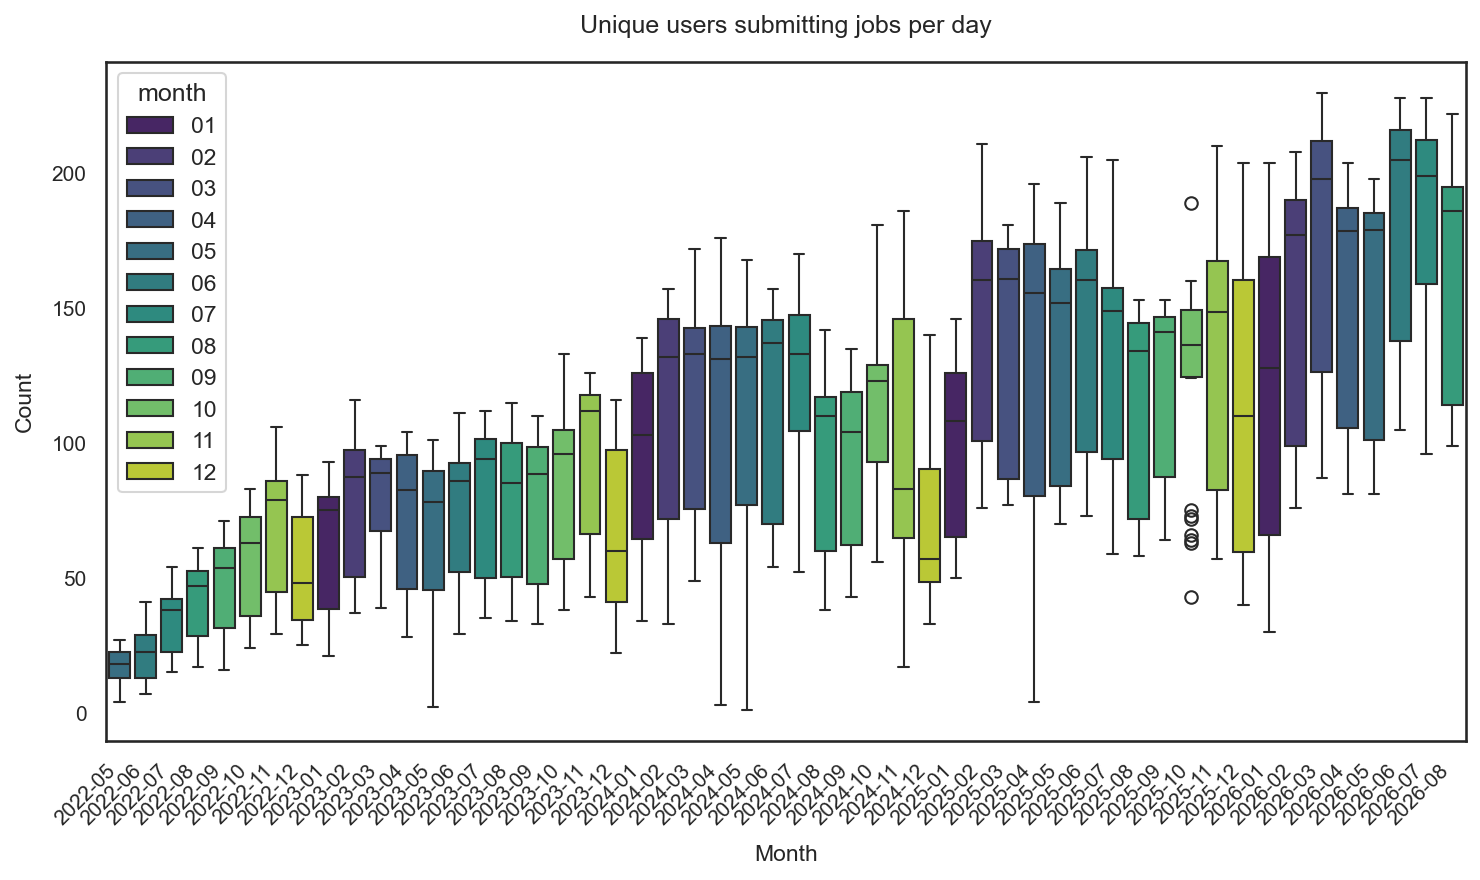

In [31]:

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_to_plot, x='submit_month', y='username', hue='month', 
            hue_order=legend_order, palette='viridis')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Unique users submitting jobs per day')
plt.tight_layout()
plt.show()